In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [33]:
df =pd.read_csv("02.loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [34]:
# df.isnull().sum()
object_colum = df.select_dtypes(include=["object"]).columns
number_colum = df.select_dtypes(include=["number"]).columns

In [35]:
num_imp = SimpleImputer(strategy="mean")
df[number_colum]= num_imp.fit_transform(df[number_colum])

In [36]:
col_imp = SimpleImputer(strategy="most_frequent")
df[object_colum]= col_imp.fit_transform(df[object_colum])

([<matplotlib.patches.Wedge at 0x1c13362c050>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'yes'),
  Text(0.6521428261765839, -0.8858384357581341, 'no')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

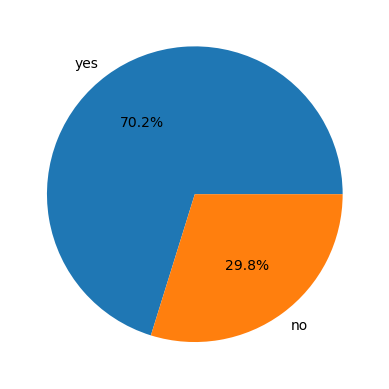

In [37]:
classes_cout = df["Loan_Approved"].value_counts()
plt.pie(classes_cout,labels=["yes","no"],autopct="%1.1f%%")

In [38]:
df = df.drop("Applicant_ID", axis=1)

In [39]:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"]= le.fit_transform(df["Loan_Approved"])
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [40]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]
on = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
encoded = on.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns=on.get_feature_names_out(cols),index=df.index)
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [41]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Loan_Approved,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,0,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, accuracy_score, recall_score


In [57]:
x = df.drop(columns="Loan_Approved")
y = df["Loan_Approved"]

In [58]:
x_train , x_test,y_train,y_test= train_test_split(x,y,random_state=42,test_size=0.2)

In [79]:
# logictic 
pipeline =Pipeline([
    ("scaller",StandardScaler()),
    ("lgg",LogisticRegression())
])
param_grid = {"lgg__max_iter":[1000]}
l_model =GridSearchCV(pipeline,param_grid=param_grid,cv=5,scoring="precision")
l_model.fit(x_train,y_train)
y_pred = l_model.predict(x_test)

In [80]:
print("precision score: ", precision_score(y_test, y_pred))

print("accuracy score: ", accuracy_score(y_test, y_pred))
print("recall score: ", recall_score(y_test, y_pred))

precision score:  0.7833333333333333
accuracy score:  0.865
recall score:  0.7704918032786885


In [81]:
pipeline1 = Pipeline([
    ("scaller",StandardScaler()),
    ("knn",KNeighborsClassifier())
])
param_grid1 = {'knn__n_neighbors': [3, 5, 7, 9,11,13]}
k_model = GridSearchCV(pipeline1,param_grid1,cv=5,scoring="precision")
k_model.fit(x_train,y_train)
ypred1= k_model.predict(x_test)

In [82]:
print("accuracy score: ", accuracy_score(y_test, ypred1))
print("precision score: ", precision_score(y_test, ypred1))
print("recall score: ", recall_score(y_test, ypred1))


accuracy score:  0.79
precision score:  0.7317073170731707
recall score:  0.4918032786885246


In [86]:
pipeline2= Pipeline([
    ("scaller",StandardScaler()),
    ("knn",GaussianNB())
])
g_model = GridSearchCV(pipeline2,param_grid={},cv=5,scoring="precision")
g_model.fit(x_train,y_train)
ypred2= g_model.predict(x_test)

In [87]:
print("accuracy score: ", accuracy_score(y_test, ypred2))
print("precision score: ", precision_score(y_test, ypred2))
print("recall score: ", recall_score(y_test, ypred2))


accuracy score:  0.865
precision score:  0.8035714285714286
recall score:  0.7377049180327869
